In [21]:
# Imports and Config
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths
RAW_DIR = 'raw_data/'
OUTPUT_FILE = 'data/final_training_data.csv'

# List of files we want to use (We pick the most relevant ones for Kubernetes)
# You can add more from your list if you want!
FILES_TO_LOAD = [
    'Syn.csv',          # TCP SYN Flood (Critical for K8s)
    'DrDoS_UDP.csv',    # UDP Flood
    'DrDoS_DNS.csv',    # DNS Reflection
    'DrDoS_SSDP.csv',   # SSDP Amplification
    'DrDoS_NTP.csv'     # NTP Amplification
]

print(f"Targeting {len(FILES_TO_LOAD)} attack datasets.")

Targeting 5 attack datasets.


In [22]:
# Load and Combine Data (UPGRADED)
frames = []

cols_to_keep = [
    ' Flow Duration', 
    ' Total Fwd Packets', 
    ' Total Backward Packets', 
    'Total Length of Fwd Packets', 
    ' Total Length of Bwd Packets', 
    ' Label'
]

for file in FILES_TO_LOAD:
    file_path = os.path.join(RAW_DIR, file)
    if os.path.exists(file_path):
        print(f"Loading {file}...")
        try:
            # UPGRADE: Reading 100,000 rows per file (5x more data)
            df_chunk = pd.read_csv(file_path, usecols=cols_to_keep, nrows=100000)
            df_chunk.columns = df_chunk.columns.str.strip()
            frames.append(df_chunk)
        except Exception as e:
            print(f"Error reading {file}: {e}")

full_df = pd.concat(frames, ignore_index=True)
print(f"Successfully loaded {len(full_df)} rows of Real Data!")

Loading Syn.csv...
Loading DrDoS_UDP.csv...
Loading DrDoS_DNS.csv...
Loading DrDoS_SSDP.csv...
Loading DrDoS_NTP.csv...
Successfully loaded 500000 rows of Real Data!


In [23]:
# Feature Engineering
print("Transforming Raw Features to Controller Format...")

# 1. Basic Stats
full_df['Total_Packets'] = full_df['Total Fwd Packets'] + full_df['Total Backward Packets']
full_df['Total_Bytes'] = full_df['Total Length of Fwd Packets'] + full_df['Total Length of Bwd Packets']
full_df['Duration_Sec'] = full_df['Flow Duration'] / 1_000_000
full_df['Duration_Sec'] = full_df['Duration_Sec'].replace(0, 0.00001)

# 2. PPS (Packets Per Second)
full_df['PPS'] = full_df['Total_Packets'] / full_df['Duration_Sec']

# 3. NEW FEATURE: Average Packet Size (The Smoking Gun)
# DDoS packets are often tiny. Normal packets are often varying sizes.
full_df['Avg_Packet_Size'] = full_df['Total_Bytes'] / full_df['Total_Packets']
full_df['Avg_Packet_Size'] = full_df['Avg_Packet_Size'].fillna(0)

# 4. Map Labels
full_df['Label_Binary'] = full_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# 5. Select FINAL columns (Added Avg_Packet_Size)
# New Features: [PPS, Bytes, Packets, Avg_Packet_Size]
final_df = full_df[['PPS', 'Total_Bytes', 'Total_Packets', 'Avg_Packet_Size', 'Label_Binary']].copy()

# Rename
final_df.columns = ['PPS', 'Bytes', 'Packets', 'Avg_Packet_Size', 'Label']

# --- BALANCING STEP (Keep this!) ---
print("Balancing Dataset...")
benign_df = final_df[final_df['Label'] == 0]
attack_df = final_df[final_df['Label'] == 1]
n_benign = len(benign_df)
attack_df_balanced = attack_df.sample(n=n_benign, random_state=42)
balanced_df = pd.concat([benign_df, attack_df_balanced])
final_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"New Balanced Dataset Size: {len(final_df)}")
print(final_df.head())

Transforming Raw Features to Controller Format...
Balancing Dataset...
New Balanced Dataset Size: 30552
            PPS   Bytes  Packets  Avg_Packet_Size  Label
0  40816.326531     0.0        2              0.0      1
1     36.695564  1398.0        4            349.5      1
2  43478.260870   802.0        2            401.0      1
3    192.233756   208.0        4             52.0      0
4    194.363460   286.0        4             71.5      0


In [24]:
# --- BALANCING STEP ---
print("Balancing Dataset...")

# Separate the classes
benign_df = final_df[final_df['Label'] == 0]
attack_df = final_df[final_df['Label'] == 1]

# Count how many benign samples we have
n_benign = len(benign_df)
print(f"Benign Samples: {n_benign} | Attack Samples: {len(attack_df)}")

# Randomly sample 'n_benign' rows from the attack data (Undersampling)
attack_df_balanced = attack_df.sample(n=n_benign, random_state=42)

# Combine them back together
balanced_df = pd.concat([benign_df, attack_df_balanced])

# Shuffle the rows so they aren't in order
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Replace 'final_df' with our new balanced version
final_df = balanced_df

print(f"New Balanced Dataset Size: {len(final_df)} (50% Attack / 50% Benign)")

Balancing Dataset...
Benign Samples: 15276 | Attack Samples: 15276
New Balanced Dataset Size: 30552 (50% Attack / 50% Benign)


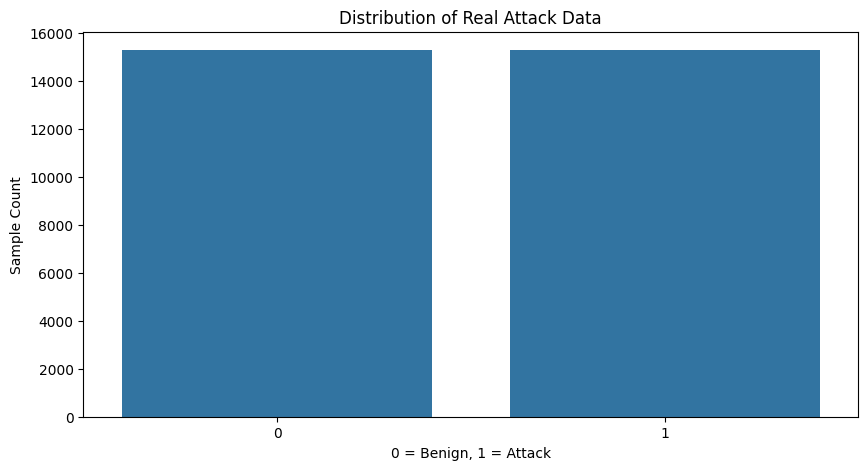

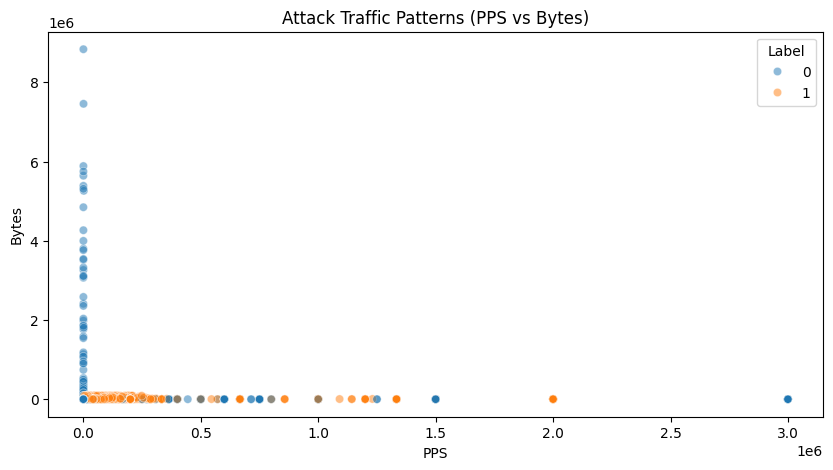

In [25]:
# Visualization
plt.figure(figsize=(10, 5))

# Plot 1: Attack vs Benign Count
sns.countplot(x='Label', data=final_df)
plt.title('Distribution of Real Attack Data')
plt.xlabel('0 = Benign, 1 = Attack')
plt.ylabel('Sample Count')
plt.show()

# Plot 2: Traffic Volume by Type
plt.figure(figsize=(10, 5))
sns.scatterplot(data=final_df, x='PPS', y='Bytes', hue='Label', alpha=0.5)
plt.title('Attack Traffic Patterns (PPS vs Bytes)')
plt.show()

In [26]:
# Save
# Handle Infinite values (common in raw network data)
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()

final_df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved processed dataset to {OUTPUT_FILE} with {len(final_df)} samples.")

Saved processed dataset to data/final_training_data.csv with 30552 samples.
